# Credit Risk Prediction using Machine Learning

## Objective

The objective of this project is to develop a machine learning model that predicts whether a loan applicant is classified as a good or bad credit risk based on demographic and financial attributes.

This project covers:

- Exploratory Data Analysis (EDA)
- Data Preprocessing
- Feature Engineering
- Model Training
- Model Evaluation
- Model Explainability using SHAP

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
%matplotlib inline

## 2. Import Libraries & Load Dataset

In [40]:
df = pd.read_csv("../Data/german_credit_data.csv")

In [41]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='str')

## 3. Data Overview

Before performing any preprocessing or modelling, it is important to understand the structure and characteristics of the dataset.

In [42]:
df.shape
df.info()
df.describe()
df.describe(include="object")
df.head()
df.sample(5,random_state=42)

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Unnamed: 0        1000 non-null   int64
 1   Age               1000 non-null   int64
 2   Sex               1000 non-null   str  
 3   Job               1000 non-null   int64
 4   Housing           1000 non-null   str  
 5   Saving accounts   817 non-null    str  
 6   Checking account  606 non-null    str  
 7   Credit amount     1000 non-null   int64
 8   Duration          1000 non-null   int64
 9   Purpose           1000 non-null   str  
 10  Risk              1000 non-null   str  
dtypes: int64(5), str(6)
memory usage: 86.1 KB


C:\Users\USER\AppData\Local\Temp\ipykernel_4072\1308280746.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
521,521,24,female,2,own,little,little,3190,18,radio/TV,bad
737,737,35,male,1,own,moderate,little,4380,18,car,good
740,740,32,male,2,own,moderate,little,2325,24,car,good
660,660,23,male,2,rent,little,rich,1297,12,radio/TV,good
411,411,35,male,3,own,little,NaN,7253,33,car,good


In [43]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


### Key Findings

- The dataset contains 1,000 loan applicants and 10 columns.
- Two features contain missing values: Saving accounts (18.3%) and Checking account (39.4%).
- The `Unnamed: 0` column is an index column and will be removed during preprocessing.
- No conclusions about feature importance are made at this stage.

## 4. Data Quality Assessment

Before building any machine learning model, it is essential to assess the quality of the dataset. This includes identifying missing values, duplicate records, unique values, and other potential issues that may affect model performance.

In [44]:
df.isnull().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

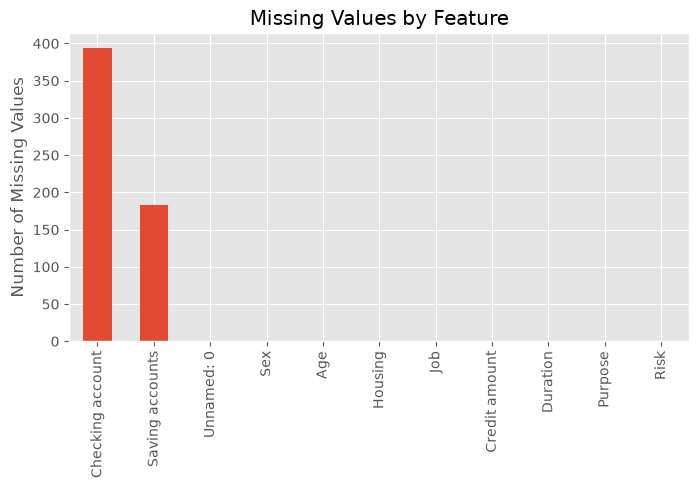

In [45]:
missing = df.isnull().sum().sort_values(ascending=False)

plt.figure(figsize=(8,4))
missing.plot(kind="bar")
plt.title("Missing Values by Feature")
plt.ylabel("Number of Missing Values")
plt.show()

In [46]:
missing_percent = (df.isnull().sum()/len(df)*100).sort_values(ascending=False)
missing_percent

Checking account    39.4
Saving accounts     18.3
Unnamed: 0           0.0
Sex                  0.0
Age                  0.0
Housing              0.0
Job                  0.0
Credit amount        0.0
Duration             0.0
Purpose              0.0
Risk                 0.0
dtype: float64

In [47]:
df.duplicated().sum()

np.int64(0)

In [48]:
df.nunique()

Unnamed: 0          1000
Age                   53
Sex                    2
Job                    4
Housing                3
Saving accounts        4
Checking account       3
Credit amount        921
Duration              33
Purpose                8
Risk                   2
dtype: int64

In [49]:
df.dtypes

Unnamed: 0          int64
Age                 int64
Sex                   str
Job                 int64
Housing               str
Saving accounts       str
Checking account      str
Credit amount       int64
Duration            int64
Purpose               str
Risk                  str
dtype: object

### Key Findings

- The dataset contains 1,000 customer records and 10 features.
- Missing values are present in the `Checking account` (39.4%) and `Saving accounts` (18.3%) columns.
- No duplicate records were found.
- The `Unnamed: 0` column appears to be an index column and is not expected to contribute to prediction.
- The dataset contains both numerical and categorical variables.
- Although `Job` is stored as an integer, it represents categorical job levels rather than continuous numerical values.

In [50]:
len(df)
len(df.dropna())
len(df) - len(df.dropna())

478

# 5 Exploratory Data Analysis (EDA)

### 5.1 Target Variable Analysis

Understanding the distribution of the target variable is essential before building a classification model. It helps determine whether the dataset is balanced or imbalanced.

In [51]:
df["Risk"].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

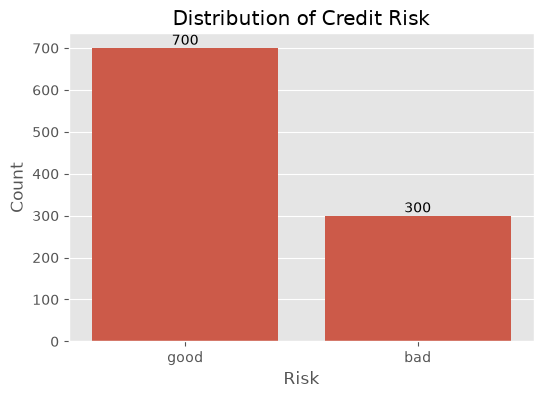

In [52]:
plt.figure(figsize=(6,4))

ax = sns.countplot(data=df, x="Risk")

plt.title("Distribution of Credit Risk")
plt.xlabel("Risk")
plt.ylabel("Count")

# Tambah nilai atas setiap bar
for container in ax.containers:
    ax.bar_label(container)

plt.show()

#### Interpretation

The target variable is moderately imbalanced, with 700 customers classified as **good** credit risk (70%) and 300 customers classified as **bad** credit risk (30%). Although the imbalance is not severe, it should be considered during model development and evaluation. Appropriate evaluation metrics, such as Precision, Recall, F1-score, and ROC-AUC, will be used instead of relying solely on accuracy.

### 5.2 Numerical Features Analysis

#### Visualization Function

To ensure consistency and improve code reusability, a custom visualization function is created for all numerical features. This function generates both a histogram and a boxplot side by side, providing a comprehensive view of each feature's distribution and potential outliers. Using a reusable function also reduces code duplication and makes the notebook easier to maintain and extend.


In [53]:
def plot_numerical_feature(df, column, bins=20):
    plt.figure(figsize=(14,5))

    plt.subplot(1,2,1)
    sns.histplot(data=df, x=column, bins=bins, kde=True)
    plt.title(f"{column} Distribution")
    plt.xlabel(column)
    plt.ylabel("Frequency")

    plt.subplot(1,2,2)
    sns.boxplot(data=df, x=column)
    plt.title(f"{column} Boxplot")
    plt.xlabel(column)

    plt.tight_layout()
    plt.show()

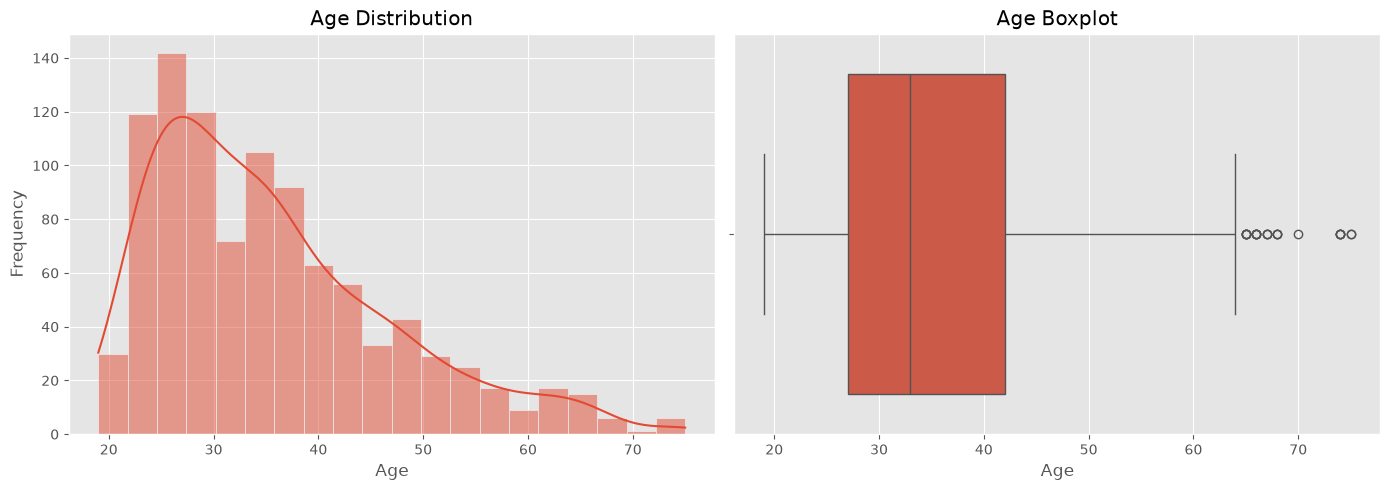

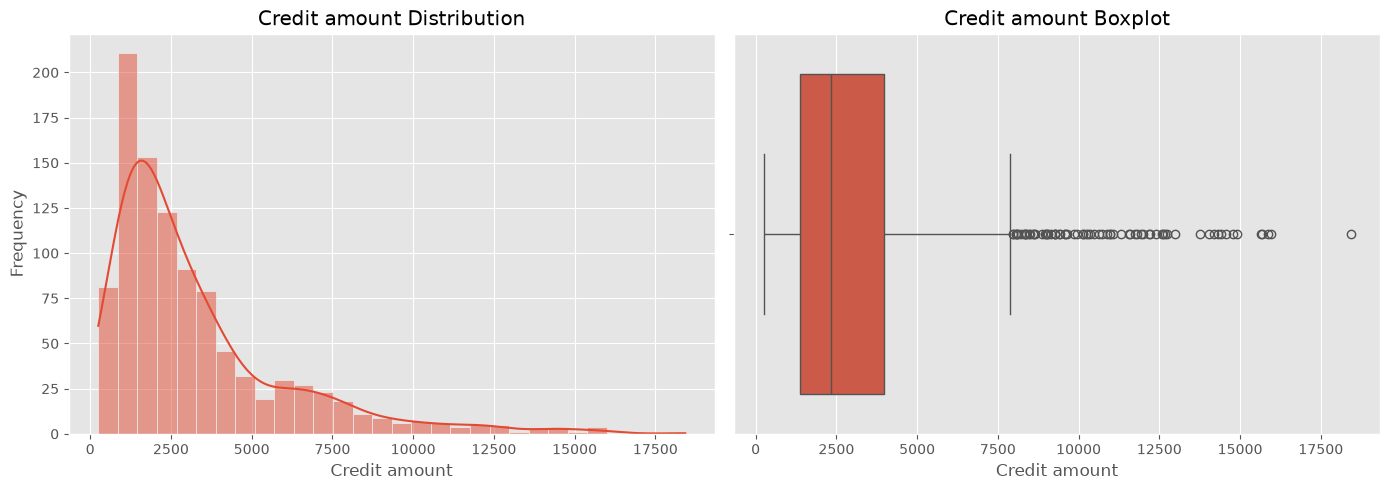

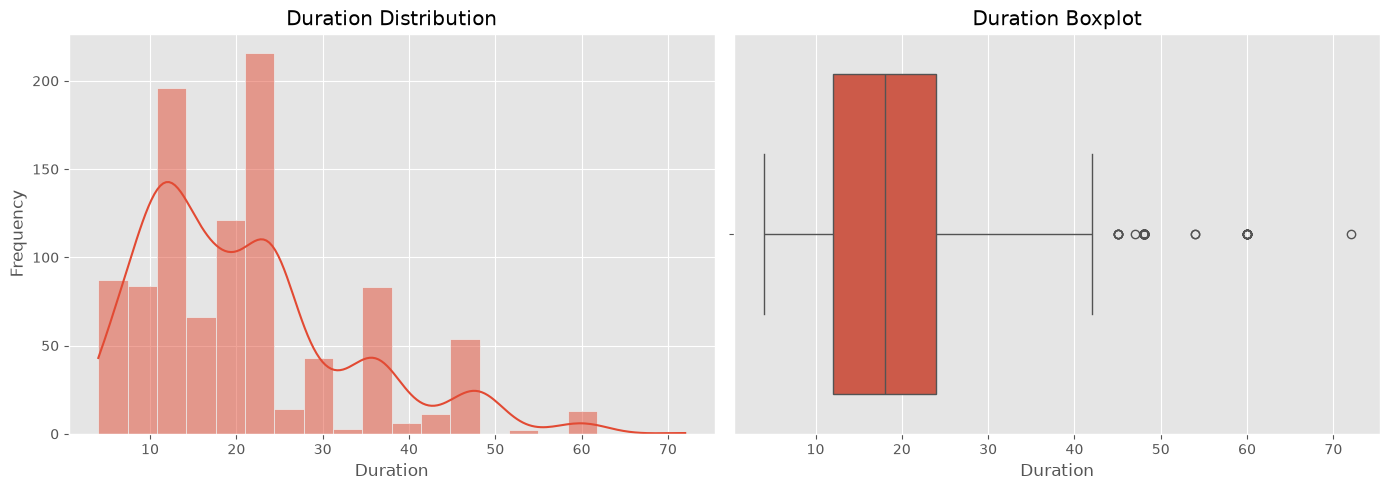

In [54]:
plot_numerical_feature(df, "Age", bins=20)

plot_numerical_feature(df, "Credit amount", bins=30)

plot_numerical_feature(df, "Duration", bins=20)

#### Interpretation

The distributions of the numerical features provide valuable insights into the characteristics of the loan applicants. The **Age** feature shows that most applicants are relatively young to middle-aged, with only a few older applicants appearing as potential outliers. The **Credit amount** distribution is positively skewed, indicating that most applicants requested smaller loan amounts, while a small number applied for substantially larger loans. Similarly, the **Duration** feature is concentrated around shorter loan periods, with relatively few long-term loans.

The boxplots reveal the presence of several outliers, particularly in the **Credit amount** feature. These observations are expected in financial datasets and should not be removed without proper justification, as they may represent legitimate high-value loans rather than data entry errors. Overall, the numerical features appear suitable for further analysis and preprocessing before model development.


### 5.3 Categorical Features Analysis

In [55]:
def plot_categorical_feature(df, column):
    plt.figure(figsize=(8,4))

    ax = sns.countplot(data=df, x=column, order=df[column].value_counts().index)

    plt.title(f"{column} Distribution")
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.xticks(rotation=30)

    # Add value labels
    for container in ax.containers:
        ax.bar_label(container)

    plt.tight_layout()
    plt.show()

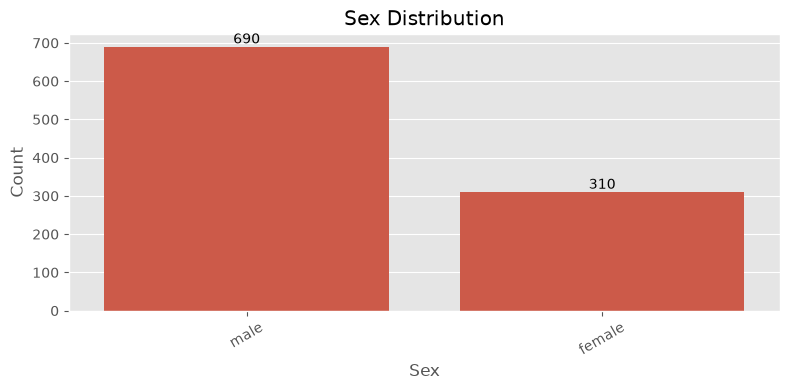

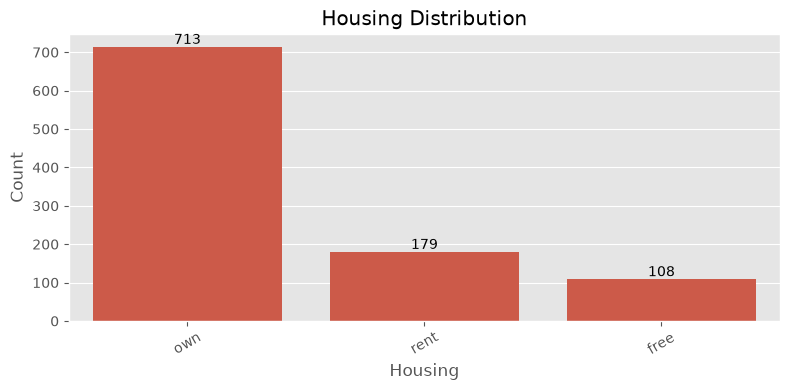

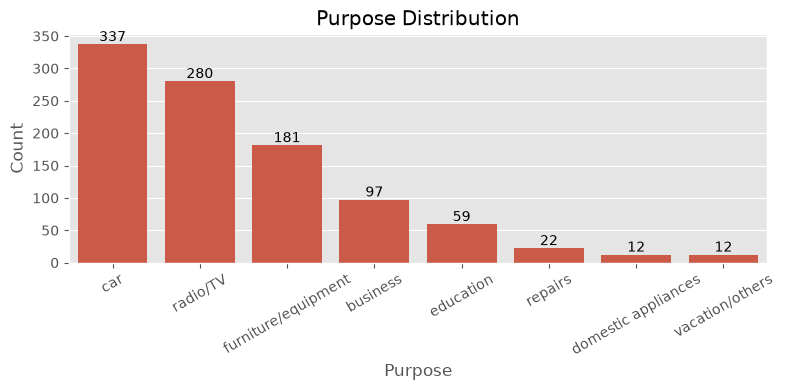

In [56]:
plot_categorical_feature(df, "Sex")
plot_categorical_feature(df, "Housing")
plot_categorical_feature(df, "Purpose")

#### Interpretation

The categorical features reveal the composition of the loan applicants across different demographic and financial categories. Most features exhibit an uneven distribution, indicating that certain categories are more common than others. In particular, the **Saving accounts** and **Checking account** features contain missing values, suggesting that not all applicants provided complete financial information.

The observed distributions provide an initial understanding of the customer population and may help explain differences in credit risk when these features are analysed against the target variable. Further analysis will examine whether specific categories are associated with a higher likelihood of being classified as a **good** or **bad** credit risk.


## 5.4 Relationship Between Features and Target

The previous analysis explored each feature individually. In this section, each feature is analysed against the target variable (**Risk**) to identify patterns that may influence credit risk classification.

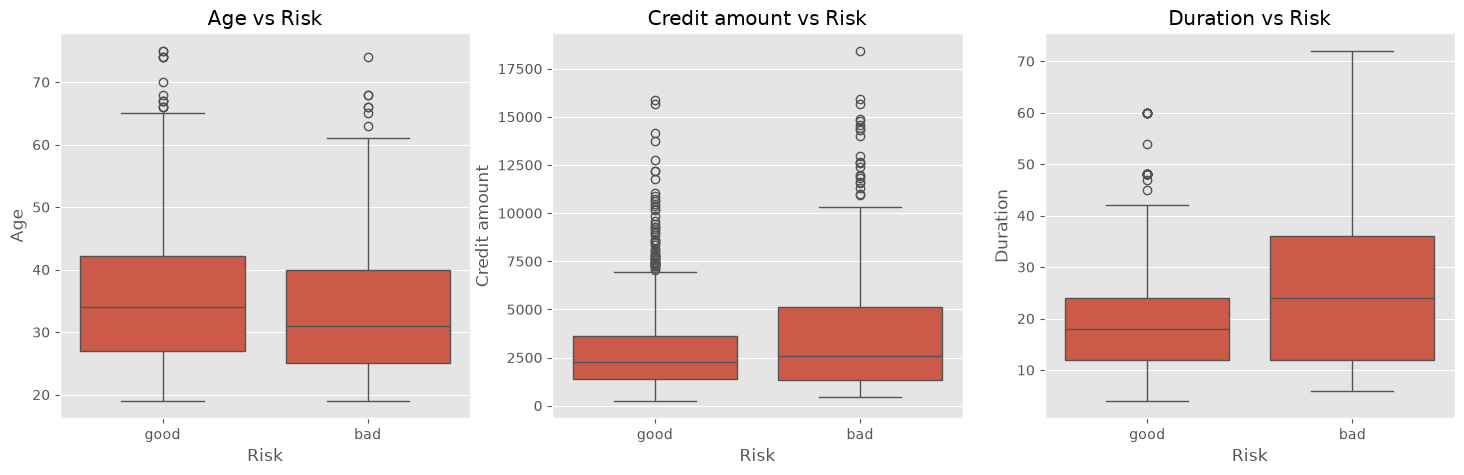

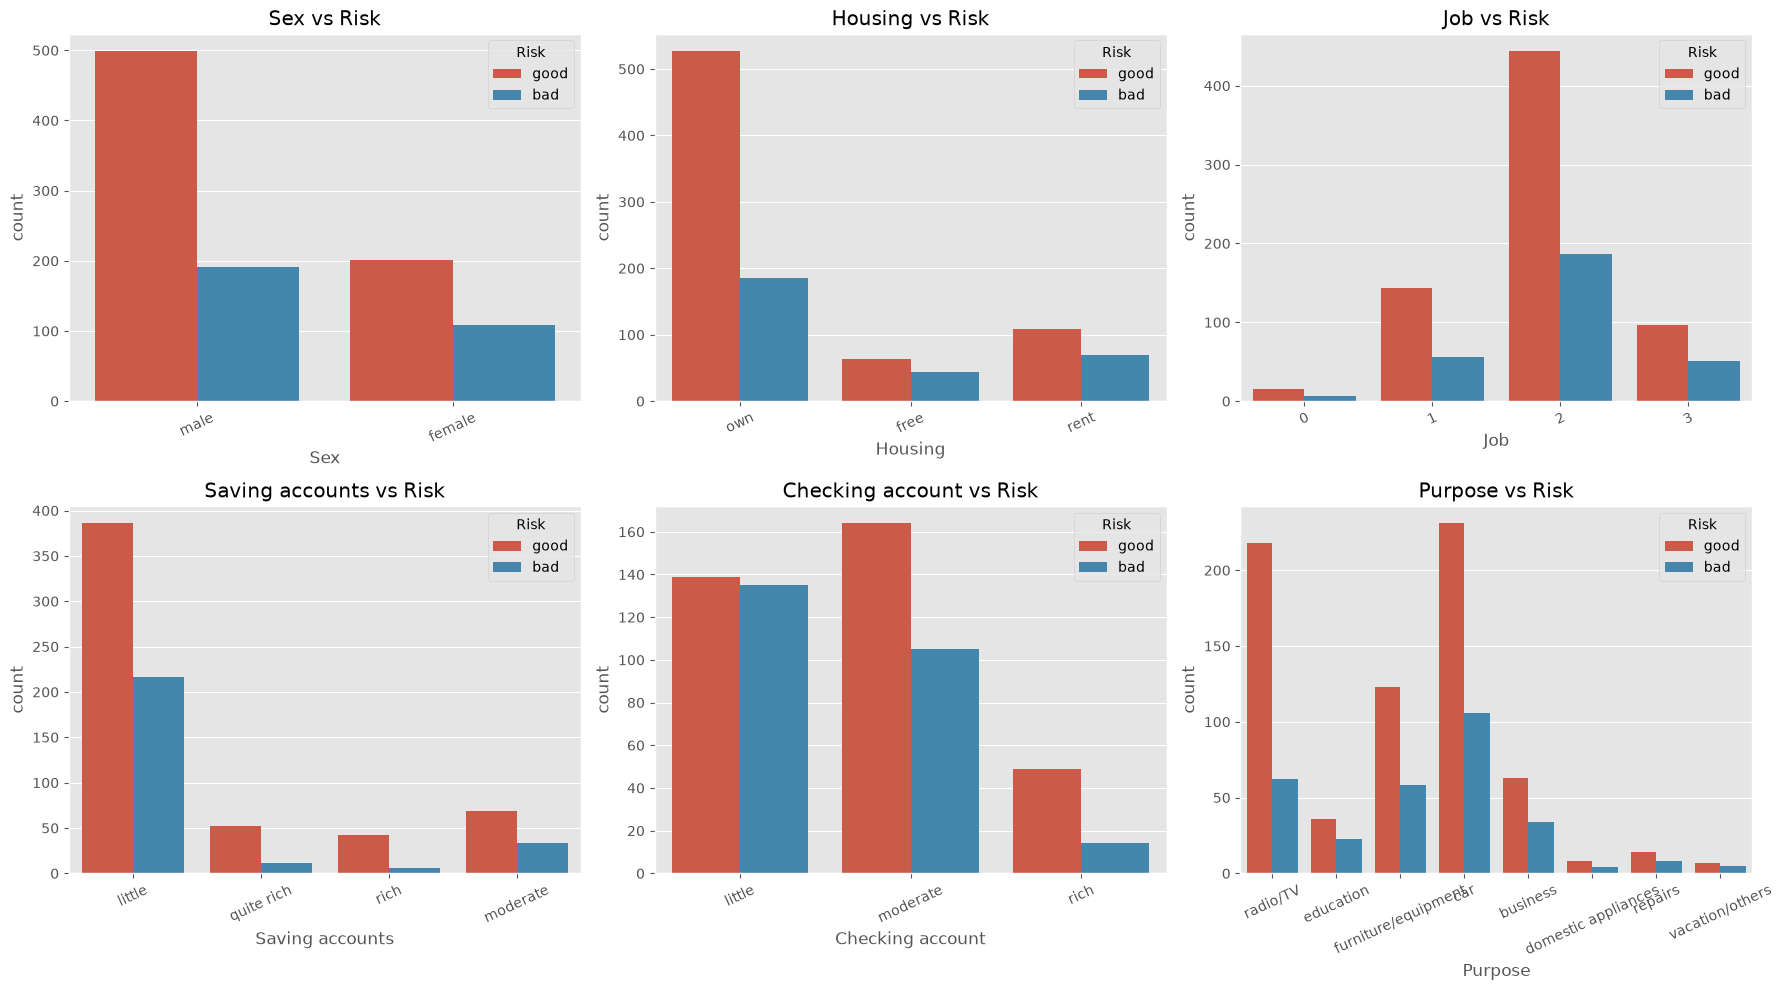

In [57]:
# Numerical features
numerical_features = ["Age", "Credit amount", "Duration"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feature in zip(axes, numerical_features):
    sns.boxplot(data=df, x="Risk", y=feature, ax=ax)
    ax.set_title(f"{feature} vs Risk")
    ax.set_xlabel("Risk")
    ax.set_ylabel(feature)

    # Categorical features
categorical_features = [
    "Sex",
    "Housing",
    "Job",
    "Saving accounts",
    "Checking account",
    "Purpose"
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, feature in zip(axes, categorical_features):
    sns.countplot(data=df, x=feature, hue="Risk", ax=ax)
    ax.set_title(f"{feature} vs Risk")
    ax.tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

#### Interpretation

The relationship analysis reveals several differences between the **good** and **bad** credit risk groups. Among the numerical features, applicants classified as **bad** credit risk generally have **higher loan amounts** and **longer loan durations** than those classified as **good** credit risk. In contrast, the age distributions of both groups are highly similar, suggesting that **Age** alone may have limited predictive power.

For the categorical features, **Housing**, **Job**, **Saving accounts**, **Checking account**, and **Purpose** exhibit noticeable differences between the two risk groups. Applicants with **moderate or rich savings accounts** appear more frequently in the good credit risk group, while those with limited or missing financial account information are relatively more common among bad credit risk applicants. Similarly, the distribution of loan purposes varies across the two classes, indicating that the purpose of borrowing may influence credit risk.

Overall, the analysis suggests that financial-related variables, particularly **Credit amount**, **Duration**, and account information, may provide stronger predictive signals than demographic characteristics such as **Age** or **Sex**. These observations will be further validated during feature importance analysis and machine learning model development.


### 5.5 Categorical Risk Proportion Analysis

The previous analysis compared the absolute number of applicants in each category. However, larger groups naturally contain more observations, which may lead to misleading conclusions. To obtain a fair comparison, this section analyses the **proportion** of good and bad credit risk within each category.


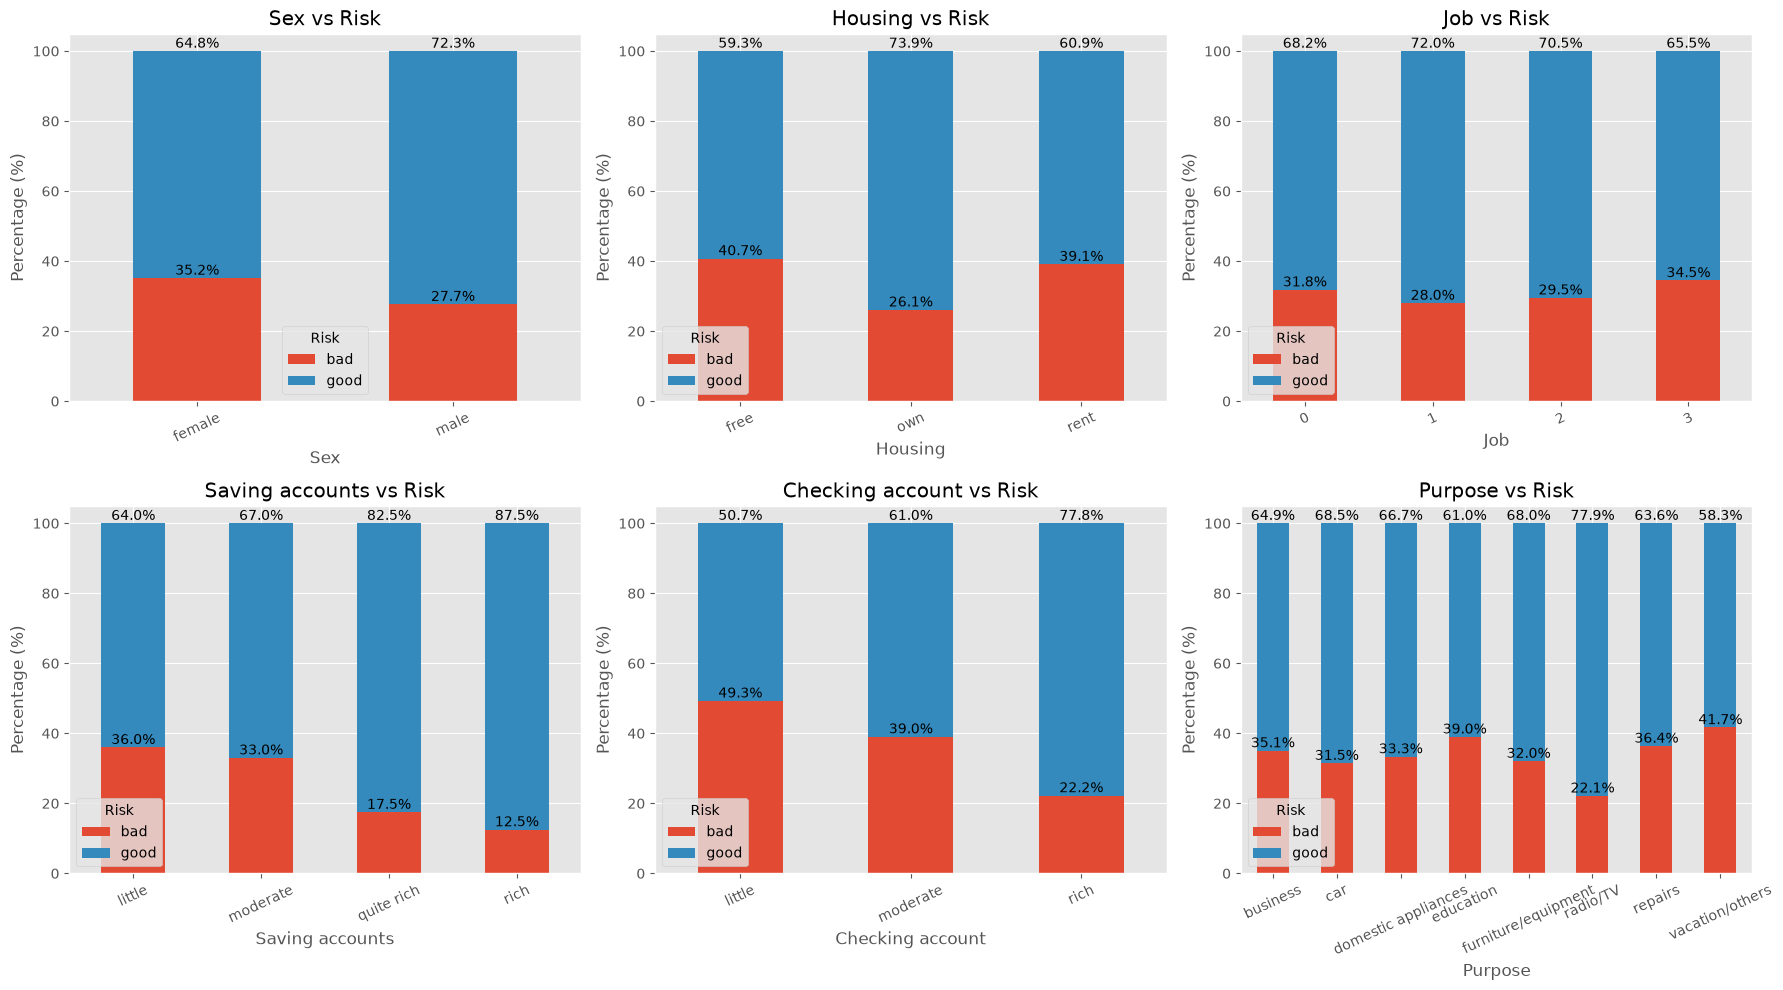

In [58]:
def plot_all_risk_proportions(df, features):
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for ax, feature in zip(axes, features):

        proportion = (
            pd.crosstab(df[feature], df["Risk"], normalize="index")
            * 100
        )

        proportion.plot(
            kind="bar",
            stacked=True,
            ax=ax
        )

        ax.set_title(f"{feature} vs Risk")
        ax.set_xlabel(feature)
        ax.set_ylabel("Percentage (%)")
        ax.tick_params(axis="x", rotation=25)

        # Add percentage labels
        for container in ax.containers:
            labels = [
                f"{v:.1f}%"
                if v > 5 else ""
                for v in container.datavalues
            ]
            ax.bar_label(container, labels=labels)

    plt.tight_layout()
    plt.show()

    categorical_features = [
    "Sex",
    "Housing",
    "Job",
    "Saving accounts",
    "Checking account",
    "Purpose"
]

plot_all_risk_proportions(df, categorical_features)

#### Interpretation

The proportional analysis reveals meaningful differences in credit risk across several categorical features. Compared with the previous count-based analysis, normalising each category by percentage provides a fairer comparison of the likelihood of applicants being classified as **good** or **bad** credit risk.

Among the analysed features, **Saving accounts** and **Checking account** exhibit the strongest separation between the two risk groups. Applicants with **rich** or **quite rich** savings accounts have a substantially higher proportion of good credit risk, whereas applicants with **little** savings or checking account balances show a noticeably higher proportion of bad credit risk. Loan **Purpose** also displays varying risk profiles across categories, suggesting that the reason for borrowing may influence creditworthiness.

In contrast, **Sex**, **Housing**, and **Job** show relatively smaller differences between categories, indicating that these demographic characteristics may have weaker predictive power than financial-related features. These findings suggest that applicants' financial status provides stronger signals for credit risk prediction than demographic information.


#### Key Insight

The proportional analysis indicates that financial-related variables are likely to be more informative predictors of credit risk than demographic characteristics. In particular, **Saving accounts**, **Checking account**, and **Purpose** demonstrate noticeable differences in the proportion of good and bad credit risk applicants, making them promising features for the classification model. These observations provide an initial hypothesis that will be validated through feature importance analysis and machine learning model performance in later stages of the project.


## 6. Data Preprocessing

Raw datasets often contain unnecessary columns, missing values, and categorical variables that cannot be directly processed by machine learning algorithms. This section prepares the dataset for model training by performing data cleaning, feature encoding, train-test splitting, and feature scaling.


### 6.1 Remove Unnecessary Features

The dataset contains an index column (**Unnamed: 0**) that does not provide predictive information. Since it merely identifies each record and has no relationship with credit risk, it will be removed before model development.


In [59]:
df = df.drop(columns=["Unnamed: 0"])

df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


### 6.2 Handle Missing Values

Missing values can negatively affect machine learning models, as many algorithms cannot process incomplete data directly. Therefore, appropriate imputation techniques are applied to preserve the dataset while minimising information loss.

In [60]:
df["Saving accounts"] = df["Saving accounts"].fillna("Unknown")

df["Checking account"] = df["Checking account"].fillna("Unknown")

In [61]:
df.isnull().sum()

Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Risk                0
dtype: int64

#### Interpretation

Missing values in the **Saving accounts** and **Checking account** features were replaced with **"Unknown"** instead of removing the affected records or imputing the most frequent category. This approach preserves all observations while allowing the machine learning model to learn whether the absence of financial account information is itself informative.

### 6.3 Separate Features and Target

Machine learning models require the input features (**X**) and the target variable (**y**) to be separated before training. The features represent the information used for prediction, while the target variable is the outcome that the model aims to predict.

In [62]:
X = df.drop(columns=["Risk"])
y = df["Risk"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (1000, 9)
Target shape: (1000,)


### 6.4 Train-Test Split

To evaluate the performance of a machine learning model fairly, the dataset is divided into separate training and testing sets. The model is trained using the training data and evaluated on previously unseen testing data to assess its ability to generalise to new observations.

A stratified sampling strategy is adopted to preserve the original distribution of the target variable (**Risk**) in both the training and testing datasets.

In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Target  :", y_train.shape)
print("Testing Target   :", y_test.shape)

Training Features: (800, 9)
Testing Features : (200, 9)
Training Target  : (800,)
Testing Target   : (200,)


#### Interpretation

The dataset has been divided into training and testing sets using an 80:20 ratio. The training set will be used to develop the machine learning models, while the testing set will be reserved exclusively for evaluating model performance. Stratified sampling ensures that the proportion of good and bad credit risk applicants remains consistent across both datasets, reducing sampling bias.

### 6.5 Feature Encoding

Machine learning algorithms require numerical input and cannot directly process categorical variables represented as text. Therefore, categorical features are converted into numerical representations through appropriate encoding techniques.

Nominal variables are transformed using One-Hot Encoding, while ordinal variables are encoded according to their natural ordering where applicable. This preserves the information contained within categorical features while enabling them to be used effectively by machine learning algorithms.

In [64]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = [
    "Sex",
    "Job",
    "Housing",
    "Saving accounts",
    "Checking account",
    "Purpose"
]

numerical_features = [
    "Age",
    "Credit amount",
    "Duration"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numerical_features)
    ]
)

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print("Encoded training shape:", X_train_encoded.shape)
print("Encoded testing shape :", X_test_encoded.shape)

Encoded training shape: (800, 23)
Encoded testing shape : (200, 23)


#### Interpretation

Categorical variables have been transformed into numerical representations suitable for machine learning algorithms. Appropriate encoding techniques were selected based on the nature of each feature to minimise unintended ordinal relationships while preserving the information contained within the original dataset.

## 7. Model Building

Multiple classification algorithms are evaluated to identify the most suitable model for predicting credit risk. A simple Logistic Regression model is used as the baseline before progressing to more complex tree-based ensemble models.

### 7.1 Logistic Regression

Logistic Regression is selected as the baseline classification model due to its simplicity, interpretability, and strong performance on binary classification problems. The results obtained from this model will serve as a benchmark for evaluating more advanced machine learning algorithms.

In [65]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_encoded, y_train)

lr_pred = lr.predict(X_test_encoded)

c:\Users\USER\Documents\XYZ Machine Learning\Credit Risk Prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### 7.2 Decision Tree

Decision Tree is a non-linear classification algorithm that partitions the dataset into a series of decision rules. Unlike Logistic Regression, it can capture more complex relationships between features without requiring linear assumptions. This model is included to evaluate whether a tree-based approach improves credit risk classification performance.

In [66]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train_encoded, y_train)

dt_pred = dt.predict(X_test_encoded)

### 7.3 Random Forest

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve predictive performance and reduce overfitting. By aggregating the predictions from many trees, Random Forest generally provides better generalisation and robustness than a single Decision Tree. This model is widely used for classification problems involving structured tabular data.

In [67]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train_encoded, y_train)

rf_pred = rf.predict(X_test_encoded)

## 8. Model Evaluation

The trained classification models are evaluated using multiple performance metrics to assess their predictive capability. Since the target variable is moderately imbalanced, evaluation is not limited to accuracy alone. Additional metrics, including Precision, Recall, F1-score, and ROC-AUC, are considered to provide a more comprehensive assessment of model performance.

### 8.1 Performance Comparison

The first stage of evaluation compares the overall performance of the trained models using Accuracy, Precision, Recall, and F1-score. These metrics provide complementary perspectives on classification performance and enable a fair comparison between Logistic Regression, Decision Tree, and Random Forest.

Among these metrics, F1-score is particularly important because it balances Precision and Recall, making it more suitable for evaluating moderately imbalanced classification problems.

In [68]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],

    "Precision": [
        precision_score(y_test, lr_pred, pos_label="good"),
        precision_score(y_test, dt_pred, pos_label="good"),
        precision_score(y_test, rf_pred, pos_label="good")
    ],

    "Recall": [
        recall_score(y_test, lr_pred, pos_label="good"),
        recall_score(y_test, dt_pred, pos_label="good"),
        recall_score(y_test, rf_pred, pos_label="good")
    ],

    "F1 Score": [
        f1_score(y_test, lr_pred, pos_label="good"),
        f1_score(y_test, dt_pred, pos_label="good"),
        f1_score(y_test, rf_pred, pos_label="good")
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.730,0.782895,0.850000,0.815068
1,Decision Tree,0.685,0.798450,0.735714,0.765799
2,Random Forest,0.750,0.800000,0.857143,0.827586


### 8.2 Classification Report

The classification report provides a detailed evaluation of each machine learning model by measuring **Precision**, **Recall**, **F1-score**, and **Support** for each credit risk class. Unlike overall accuracy, these metrics offer a more comprehensive assessment of model performance, particularly for moderately imbalanced classification problems.

By comparing these metrics across Logistic Regression, Decision Tree, and Random Forest, it is possible to identify which model achieves the best balance between correctly identifying good and bad credit risk applicants.

In [69]:
from sklearn.metrics import classification_report

models = {
    "Logistic Regression": lr_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred
}

for name, prediction in models.items():
    print("=" * 60)
    print(name)
    print(classification_report(y_test, prediction))

Logistic Regression
              precision    recall  f1-score   support

         bad       0.56      0.45      0.50        60
        good       0.78      0.85      0.82       140

    accuracy                           0.73       200
   macro avg       0.67      0.65      0.66       200
weighted avg       0.72      0.73      0.72       200

Decision Tree
              precision    recall  f1-score   support

         bad       0.48      0.57      0.52        60
        good       0.80      0.74      0.77       140

    accuracy                           0.69       200
   macro avg       0.64      0.65      0.64       200
weighted avg       0.70      0.69      0.69       200

Random Forest
              precision    recall  f1-score   support

         bad       0.60      0.50      0.55        60
        good       0.80      0.86      0.83       140

    accuracy                           0.75       200
   macro avg       0.70      0.68      0.69       200
weighted avg       0.74   

### 8.3 Confusion Matrix

A confusion matrix is used to evaluate how well each model classifies applicants into **good** and **bad** credit risk categories. It provides a breakdown of correct and incorrect predictions for each class, allowing a more detailed understanding of model performance beyond overall accuracy.

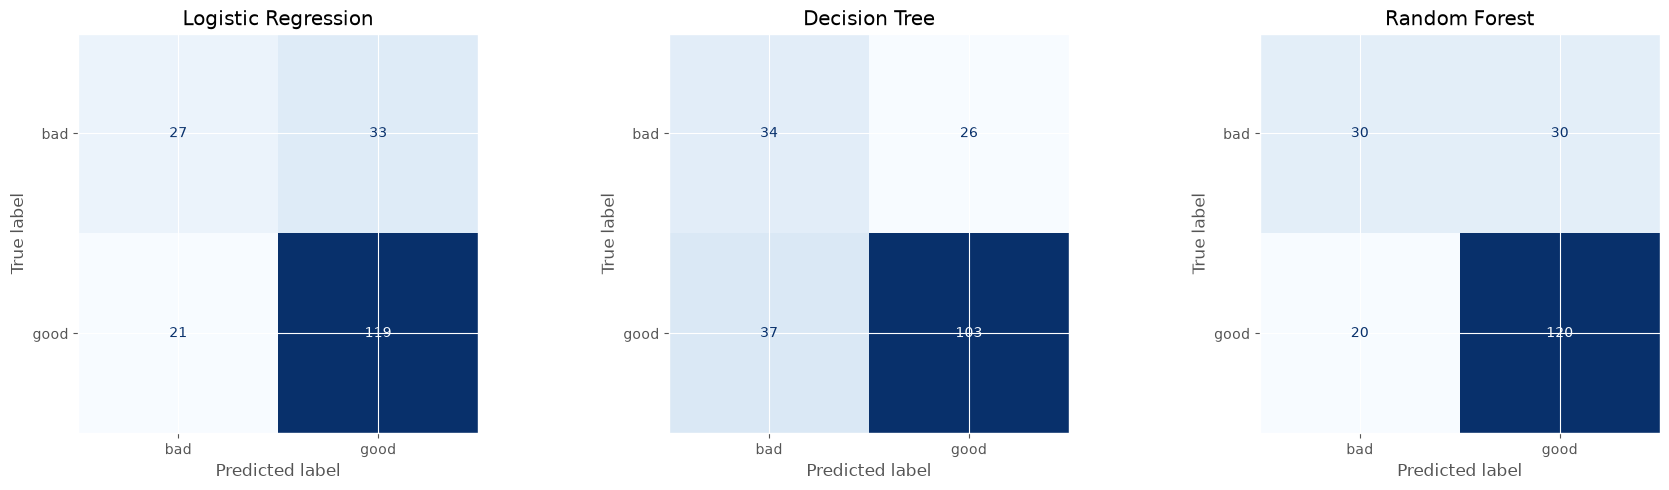

In [70]:
from sklearn.metrics import ConfusionMatrixDisplay

models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test_encoded,
        y_test,
        ax=ax,
        cmap="Blues",
        colorbar=False
    )
    ax.set_title(name)

plt.tight_layout()
plt.show()

### 8.4 ROC Curve

The ROC curve evaluates the ability of each model to distinguish between good and bad credit risk applicants across different classification thresholds. The Area Under the Curve (AUC) provides a summary measure of model discrimination, where a higher AUC indicates better separation between the two classes.

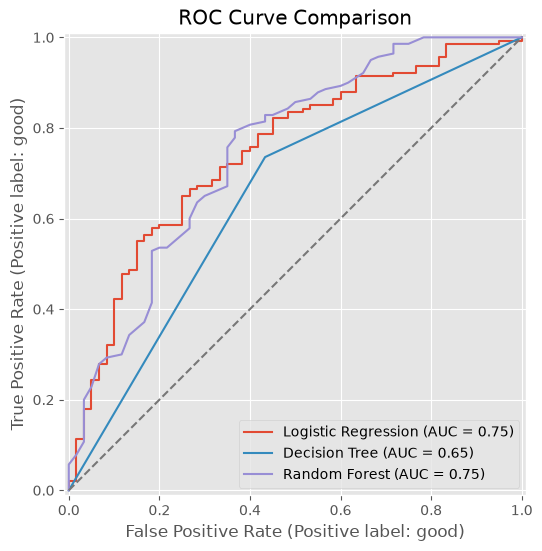

In [71]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_estimator(
    lr,
    X_test_encoded,
    y_test,
    ax=ax,
    name="Logistic Regression"
)

RocCurveDisplay.from_estimator(
    dt,
    X_test_encoded,
    y_test,
    ax=ax,
    name="Decision Tree"
)

RocCurveDisplay.from_estimator(
    rf,
    X_test_encoded,
    y_test,
    ax=ax,
    name="Random Forest"
)

plt.title("ROC Curve Comparison")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.show()

### 8.5 Best Model Selection

After evaluating the models using the performance comparison table, classification reports, confusion matrices, and ROC curves, the best-performing model is selected for further analysis. The selection is based on multiple metrics rather than accuracy alone, with particular attention given to F1-score, ROC-AUC, and the model's ability to identify bad credit risk applicants.

#### Interpretation

Among the evaluated models, **Random Forest** achieved the highest overall accuracy and F1-score, with an accuracy of **0.750** and an F1-score of **0.828** for the positive class used in the evaluation. Logistic Regression also performed competitively, achieving a similar ROC-AUC score of **0.75**, while Decision Tree showed weaker overall performance with a lower ROC-AUC of **0.65**.

The confusion matrices show that all models perform better at identifying **good** credit risk applicants than **bad** credit risk applicants. This is expected because the dataset contains more good applicants than bad applicants. However, in a credit risk context, correctly identifying bad credit risk applicants is especially important, as misclassifying them as good could lead to financial losses.

Based on the overall evaluation, **Random Forest** is selected as the best-performing model for further analysis. However, its ability to detect bad credit risk applicants can still be improved through hyperparameter tuning, class balancing techniques, or threshold optimisation.

#### Key Insight

Random Forest provides the strongest overall performance among the evaluated models, but the relatively weak detection of bad credit risk applicants suggests that further optimisation is needed. For credit risk prediction, the model should not only achieve high overall accuracy but also minimise false negatives for bad credit risk applicants.

## 9. Hyperparameter Tuning

Although the initial Random Forest model achieved the best overall performance, its predictive capability may be further improved by optimising its hyperparameters. Hyperparameter tuning aims to identify the combination of model parameters that produces the best generalisation performance while reducing overfitting.

In this study, **Grid Search with 5-fold cross-validation** is employed to systematically evaluate different combinations of hyperparameters. The best-performing parameter set is then used to train the final Random Forest model.

In [72]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Hyperparameter grid
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# Grid Search
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1
)

# Train
grid_search.fit(X_train_encoded, y_train)

# Best model
best_rf = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Score:")
print(round(grid_search.best_score_, 4))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters:
{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}

Best Cross Validation Score:
0.6945


In [73]:
best_rf = grid_search.best_estimator_

best_rf_pred = best_rf.predict(X_test_encoded)

In [74]:
tuned_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Original RF": [
        accuracy_score(y_test, rf_pred),
        precision_score(y_test, rf_pred, pos_label="good"),
        recall_score(y_test, rf_pred, pos_label="good"),
        f1_score(y_test, rf_pred, pos_label="good")
    ],
    "Tuned RF": [
        accuracy_score(y_test, best_rf_pred),
        precision_score(y_test, best_rf_pred, pos_label="good"),
        recall_score(y_test, best_rf_pred, pos_label="good"),
        f1_score(y_test, best_rf_pred, pos_label="good")
    ]
})

tuned_results.round(3)

,Metric,Original RF,Tuned RF
0,Accuracy,0.750,0.805
1,Precision,0.800,0.818
2,Recall,0.857,0.929
3,F1 Score,0.828,0.870


# Conclusion

The optimised Random Forest model outperformed the original model across all evaluation metrics. Following hyperparameter tuning using Grid Search with five-fold cross-validation, the model's accuracy increased from **75.0%** to **80.5%**, while the F1-score improved from **0.828** to **0.870**.

The tuned model also achieved higher Precision and Recall, indicating improved capability in correctly identifying credit risk applicants while reducing misclassification. These results demonstrate that selecting appropriate hyperparameters can substantially enhance the predictive performance and generalisation ability of the Random Forest classifier.

Based on these findings, the tuned Random Forest model is selected as the final model for subsequent feature importance analysis and model explainability.